<a href="https://colab.research.google.com/github/Candecano/AFD/blob/main/AFDactualizado.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Simulación Interactiva de un Autómata Finito Determinista (AFD)

Este programa implementa y simula de forma interactiva un Autómata Finito Determinista (AFD) para reconocer cadenas binarias que terminan en "01".


---

#### **Definición Formal del AFD**

El AFD está formalmente definido por la quíntupla $(Q, \Sigma, \delta, q_0, F)$, donde:

*   **Conjunto de Estados (Q):** $Q = \{q_0, q_1, q_2\}$
*   **Alfabeto de Entrada (\Sigma):** $\Sigma = \{0, 1\}$
*   **Estado Inicial ($q_0$):** El estado inicial es $q_0$.
*   **Estados de Aceptación (F):** $F = \{q_2\}$
*   **Función de Transición (\delta):** Se define a continuación en la tabla.

In [ ]:
#@title Automata Finito Determinista

def dibujar_camino_afd(definicion_afd, ruta_estados, cadena_entrada, nombre_archivo='diagrama_camino_afd'):
    """

    Variables:
        definicion_afd: diccionario que define el AFD
        ruta_estados: lista de estados que el AFD recorrio para la cadena de entrada.
        cadena_entrada: cadena de entrada que se simulo

    """
    dot = graphviz.Digraph(comment=f'Camino AFD para "{cadena_entrada}"', graph_attr={'rankdir': 'LR'})

    # añadir estados al diagrama
    for estado in sorted(list(definicion_afd['estados'])):
        if estado in definicion_afd['estados_aceptacion']:
            if estado == ruta_estados[-1] and ruta_estados[-1] in definicion_afd['estados_aceptacion']:
                # Estado final y aceptado resaltado en verde
                dot.node(estado, shape='doublecircle', style='filled', fillcolor='lightgreen', fontcolor='black')
            else:
                dot.node(estado, shape='doublecircle')
        else:
            if estado == ruta_estados[-1] and ruta_estados[-1] not in definicion_afd['estados_aceptacion']:
                # Estado final pero no aceptado en rojo
                dot.node(estado, shape='circle', style='filled', fillcolor='lightcoral', fontcolor='black')
            else:
                dot.node(estado, shape='circle')

    #nodo invisible y  flecha para indicar el estado inicial
    dot.node('inicio', shape='none', label='', width='0', height='0')
    dot.edge('inicio', definicion_afd['estado_inicial'])

    # se resalta el camino tomado
    for i in range(len(ruta_estados) - 1):
        estado_origen = ruta_estados[i]
        estado_destino = ruta_estados[i+1]
        # Asegurarse de que el indice no exceda la longitud de cadena_entrada
        simbolo_leido = cadena_entrada[i] if i < len(cadena_entrada) else ''
        dot.edge(estado_origen, estado_destino, label=simbolo_leido, color='blue', penwidth='2.0', fontcolor='blue')

    print(f"\n### Diagrama de Estados con camino para '{cadena_entrada}' ###\n")
    display(dot)

In [ ]:
#@title Definición del AFD en Python y función para mostrar la tabla de transición

# Definición del Autómata Finito Determinista (AFD)
# Se representa como un diccionario para facilitar el acceso a sus componentes.
afd = {
    'estados': {'q0', 'q1', 'q2'},                 # Conjunto de todos los estados
    'alfabeto': {'0', '1'},                      # Alfabeto de entrada
    'estado_inicial': 'q0',                         # Estado inicial
    'estados_aceptacion': {'q2'},                     # Conjunto de estados de aceptación
    'transiciones': {                             # Función de transición (delta)
        # Formato: 'estado_actual': {'símbolo': 'siguiente_estado'}
        'q0': {'0': 'q1', '1': 'q0'},  # Transiciones desde el estado q0
        'q1': {'0': 'q1', '1': 'q2'},  # Transiciones desde el estado q1
        'q2': {'0': 'q1', '1': 'q0'}   # Transiciones desde el estado q2
    }
}

def imprimir_tabla_transicion(definicion_afd):

    print("\n### Tabla de Transición del AFD\n")

    simbolos_ordenados = sorted(list(definicion_afd['alfabeto']))

    # Calcula un ancho adecuado para la columna de estado
    # Maxima longitud del nombre del estado + espacio para '-> ' y ' *'
    max_longitud_estado = max(len(s) for s in definicion_afd['estados'])
    ancho_columna_estado = max_longitud_estado + 5 # 3 para '-> ', 2 para ' *'

    encabezado_estado = "{:<{}}".format("Estado", ancho_columna_estado)
    encabezado_simbolos = ""
    for simbolo in simbolos_ordenados:
        encabezado_simbolos += "{:^15}".format(f"δ(q, '{simbolo}')") # Centra el encabezado para cada símbolo

    encabezado = encabezado_estado + encabezado_simbolos
    print(encabezado)
    print("-" * len(encabezado))

    estados_ordenados = sorted(list(definicion_afd['estados']))
    for estado in estados_ordenados:
        estado_a_mostrar = estado
        # Añade un indicador de estado inicial
        if estado == definicion_afd['estado_inicial']:
            estado_a_mostrar = "-> " + estado_a_mostrar
        # Añade un indicador de estado de aceptación
        if estado in definicion_afd['estados_aceptacion']:
            estado_a_mostrar += " *"

        fila = "{:<{}}".format(estado_a_mostrar, ancho_columna_estado) # Alineación izquierda para el estado en la fila
        for simbolo in simbolos_ordenados:
            # Obtiene el siguiente estado.
            siguiente_estado = definicion_afd['transiciones'][estado].get(simbolo, '-')
            fila += "{:^15}".format(siguiente_estado)
        print(fila)
    print("\n")

# Mostrar la tabla de transición del AFD definido
imprimir_tabla_transicion(afd)


### Tabla de Transición del AFD

Estado    δ(q, '0')      δ(q, '1')   
-------------------------------------
-> q0        q1             q0       
q1           q1             q2       
q2 *         q1             q0       




In [ ]:
#@title Función de simulación paso a paso del AFD

def simular_afd(definicion_afd, cadena_entrada):

    estado_actual = definicion_afd['estado_inicial'] # El automata siempre comienza en el estado inicial.
    ruta_estados = [estado_actual]                  # Lista para almacenar el recorrido de estados.
    resultado_aceptacion = None

    print(f"\n--- Simulando cadena: '{cadena_entrada}' ---")
    print(f"Estado inicial: {estado_actual}\n")

    # Verifica que la cadena no este vacia antes de que empiece a leer los simbolos
    if not cadena_entrada:
        print("La cadena de entrada esta vacia.")
        # Para cadenas vacias, se acepta si el estado inicial es un estado de aceptacion.
        if estado_actual in definicion_afd['estados_aceptacion']:
            print("Recorrido de estados: 'q0'")
            print(f"Estado final alcanzado: '{estado_actual}'")
            print("Resultado: \033[92mCadena ACEPTADA\033[0m (El estado final es de aceptacion).")
            resultado_aceptacion = True
        else:
            print("Recorrido de estados: 'q0'")
            print(f"Estado final alcanzado: '{estado_actual}'")
            print("Resultado: \033[91mCadena RECHAZADA\033[0m (El estado final NO es de aceptacion).")
            resultado_aceptacion = False
        return resultado_aceptacion, ruta_estados

    # Recorre la cadena simbolo por simbolo
    for i, simbolo in enumerate(cadena_entrada):
        # Verifica que el simbolo pertenece al alfabeto del AFD
        if simbolo not in definicion_afd['alfabeto']:
            print(f"Error: El símbolo '{simbolo}' en la posición {i+1} no pertenece al alfabeto del AFD ({definicion_afd['alfabeto']}).")
            return None, None # Devuelve None para indicar un error de entrada

        # Obitiene el siguiente estado de la tabla de transiciones
        siguiente_estado = definicion_afd['transiciones'][estado_actual].get(simbolo)

        # Muestra el recorrido paso a paso
        print(f"Paso {i+1}: En estado '{estado_actual}', leyendo '{simbolo}' -> va a estado '{siguiente_estado}'.")
        estado_actual = siguiente_estado # Actualiza el estado actual por el siguiente estado
        ruta_estados.append(estado_actual) # Registra el estado en el camino

    print(f"\n--- Resumen de la simulacion ---")
    print(f"Cadena ingresada: '{cadena_entrada}'")
    print(f"Recorrido de estados: {' -> '.join(ruta_estados)}")
    print(f"Estado final alcanzado: '{estado_actual}'")

    # Verifica si el estado final es un estado de aceptacion
    if estado_actual in definicion_afd['estados_aceptacion']:
        print("Resultado: \033[92mCadena ACEPTADA\033[0m (El estado final es de aceptación). ")
        resultado_aceptacion = True
    else:
        print("Resultado: \033[91mCadena RECHAZADA\033[0m (El estado final NO es de aceptación). ")
        resultado_aceptacion = False

    return resultado_aceptacion, ruta_estados

#### ** Modo Interactivo: Prueba tus propias cadenas**

Con esto se puede ingresar cadenas binarias para probar el AFD y te mostrara el camino recorrido paso a paso con el resultado final.

**Instrucciones:**
1.  Ejecuta el programa.
2.  Ingresa una cadena que contenga `0`s y `1`s.
3.  Presiona `Enter`.
4.  Para terminar, escribe `salir` y presiona `Enter`.


           MODO INTERACTIVO AFD          

Ingresa cadenas binarias (solo '0' y '1'). Escribe 'salir' para finalizar.


--- Simulando cadena: '0101' ---
Estado inicial: q0

Paso 1: En estado 'q0', leyendo '0' -> va a estado 'q1'.
Paso 2: En estado 'q1', leyendo '1' -> va a estado 'q2'.
Paso 3: En estado 'q2', leyendo '0' -> va a estado 'q1'.
Paso 4: En estado 'q1', leyendo '1' -> va a estado 'q2'.

--- Resumen de la simulacion ---
Cadena ingresada: '0101'
Recorrido de estados: q0 -> q1 -> q2 -> q1 -> q2
Estado final alcanzado: 'q2'
Resultado: Cadena ACEPTADA (El estado final es de aceptación). 

### Diagrama de Estados con camino para '0101' ###



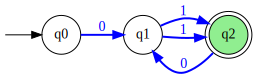


-----------------------------------------



In [ ]:
#@title Bucle interactivo para probar cadenas

print("\n=========================================")
print("           MODO INTERACTIVO AFD          ")
print("=========================================\n")
print("Ingresa cadenas binarias (solo '0' y '1'). Escribe 'salir' para finalizar.\n")

while True:
    entrada_usuario = input("Ingresa una cadena: ").strip() # .strip() para eliminar espacios en blanco al inicio/final

    if entrada_usuario.lower() == 'salir':
        print("\nSaliendo del simulador interactivo. ¡Hasta luego!")
        break # Sale del bucle

    # La validación de los símbolos de la cadena ahora se realiza únicamente dentro de `simular_afd`
    # que ya maneja los errores de símbolos no válidos.
    # Si la cadena está vacía, `simular_afd` también la maneja.

    resultado_aceptacion, ruta_estados = simular_afd(afd, entrada_usuario)

    # Si la simulación fue exitosa (no hubo errores de símbolos no válidos)
    if resultado_aceptacion is not None:
        # 'graphviz' debe estar importado para que 'dibujar_camino_afd' funcione.
        # Si no lo está, se necesitaría un 'import graphviz' en una celda previa.
        try:
            import graphviz
            dibujar_camino_afd(afd, ruta_estados, entrada_usuario)
        except ImportError:
            print("Advertencia: La librería 'graphviz' no está instalada o importada. No se puede dibujar el diagrama.")
    print("\n-----------------------------------------\n")
